In [1]:
# import libraries
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("youssefsalahzakria/fruit-and-vegetables-classification")

print("Path to dataset files:", path)

 46%|████▌     | 2.22G/4.82G [00:26<00:32, 85.0MB/s]

In [ ]:
# Paths

# DATA_DIR = "dataset"
DATA_DIR = path

MODEL_PATH = "models/ingredient_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCH_PHASE_1 = 25
EPOCH_PHASE_2 = 15

In [ ]:
# Datagen preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Add validation and test datagen
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR + "/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

In [ ]:
# Model compilation

base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze for fast training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# add earlystoping callbacks
Callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.25, patience=3, verbose=1)
]

print(model.summary())

In [ ]:
# First phase: train top layers only
print("\n Phase 1: Training top layers only...")
history_1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH_PHASE_1,
    callbacks=Callbacks
)

# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved after Phase 1.")


In [ ]:
# Second phase: fine-tuning

# unfreeze last few layers
fine_tune_layers = int(len(base_model.layers) * 0.75)  # unfreeze last 25%
for layer in base_model.layers[:fine_tune_layers]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_layers:]:
    layer.trainable = True


# recompile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )


In [ ]:
print("\n Phase 2: Fine-tuning last layers of MobileNetV2...")
history_2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH_PHASE_2,
    callbacks=Callbacks
)


# Save final model
model.save(MODEL_PATH.replace(".h5", "_final.h5"))
print(f"Final fine-tuned model saved after Phase 2.")


 Phase 2: Fine-tuning last layers of MobileNetV2...
Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 251s 604ms/step - accuracy: 0.7393 - loss: 0.9847 - val_accuracy: 0.9544 - val_loss: 0.2162 - learning_rate: 1.0000e-05
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 234s 600ms/step - accuracy: 0.7624 - loss: 0.8298 - val_accuracy: 0.9487 - val_loss: 0.2076 - learning_rate: 1.0000e-05
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.7970 - loss: 0.6672
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
390/390 ━━━━━━━━━━━━━━━━━━━━ 234s 599ms/step - accuracy: 0.7913 - loss: 0.6961 - val_accuracy: 0.9487 - val_loss: 0.2074 - learning_rate: 1.0000e-05
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 233s 597ms/step - accuracy: 0.7926 - loss: 0.6888 - val_accuracy: 0.9487 - val_loss: 0.2074 - learning_rate: 2.5000e-06
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 234s 600ms/step - accuracy: 0.8055 - loss: 0.6452 - val_accuracy: 0.9459 - val_loss: 0.2112 - learning_rate: 2.500

Final fine-tuned model saved after Phase 2.


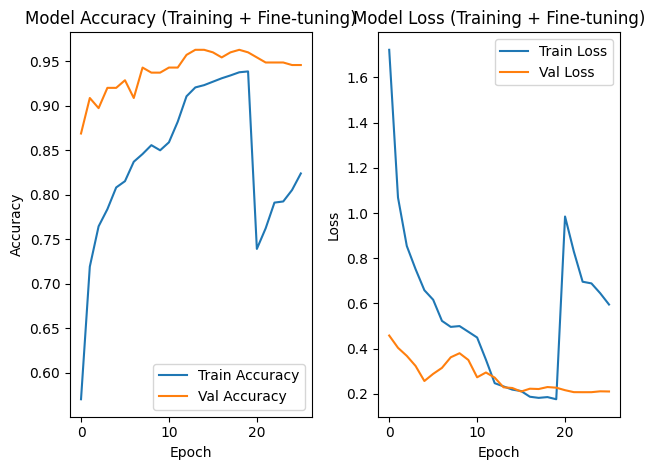

In [ ]:
# Plot training history

acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Model Accuracy (Training + Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Model Loss (Training + Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

